# Demand Forecasting & Inventory Optimization
## Section 2: Exploratory Data Analysis (EDA) & ABC Classification

In this section, we analyze the cleaned supply chain data to understand what we are dealing with before building forecasting models. Specifically, we will:
1. **ABC Analysis**: Classify products into Fast-Movers (A), Medium-Movers (B), and Slow-Movers (C) based on their contribution to revenue.
2. **Demand Trends**: Visualize historical demand for top products to check for seasonality and spikes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the clean dataset
df = pd.read_csv('clean_supply_chain_data.csv', parse_dates=['order_date', 'shipping_date'])
print(f"Data loaded successfully. Shape: {df.shape}")


Data loaded successfully. Shape: (180519, 12)


### 1. ABC Analysis (Inventory Classification)
Not all products are created equal. In supply chain, the **80/20 rule (Pareto Principle)** often applies: 20% of your products drive 80% of your revenue. 

We will classify products based on their total sales revenue:
* **Class A (Fast-Movers):** Top products making up 80% of total revenue. These require highly accurate forecasting.
* **Class B (Medium-Movers):** Next 15% of revenue.
* **Class C (Slow-Movers):** Bottom 5% of revenue. These can often be managed with simple rules rather than complex models.

In [2]:
# Calculate total revenue per product
product_sales = df.groupby('product_name')['Order Item Total'].sum().reset_index()
product_sales = product_sales.rename(columns={'Order Item Total': 'Total Revenue'})

# Sort products by total revenue in descending order
product_sales = product_sales.sort_values(by='Total Revenue', ascending=False)

# Calculate cumulative percentage of revenue
total_revenue = product_sales['Total Revenue'].sum()
product_sales['Cumulative Revenue'] = product_sales['Total Revenue'].cumsum()
product_sales['Cumulative %'] = (product_sales['Cumulative Revenue'] / total_revenue) * 100

# Function to assign ABC classes
def assign_abc_class(cum_pct):
    if cum_pct <= 80:
        return 'A'
    elif cum_pct <= 95:
        return 'B'
    else:
        return 'C'

product_sales['ABC_Class'] = product_sales['Cumulative %'].apply(assign_abc_class)

# Summary of ABC Analysis
abc_summary = product_sales.groupby('ABC_Class').agg(
    Number_of_Products=('product_name', 'count'),
    Total_Revenue=('Total Revenue', 'sum')
).reset_index()

abc_summary['% of Total Products'] = (abc_summary['Number_of_Products'] / len(product_sales)) * 100
abc_summary['% of Total Revenue'] = (abc_summary['Total_Revenue'] / total_revenue) * 100

abc_summary.round(2)


,ABC_Class,Number_of_Products,Total_Revenue,% of Total Products,% of Total Revenue
0,A,7,25409313.59,5.93,76.87
1,B,16,5978778.43,13.56,18.09
2,C,95,1666310.37,80.51,5.04


As we can see, a small percentage of products (Class A) are driving the vast majority of our revenue. When we build our forecasting model in the next section, these are the items we care about the most.

Let's visualize this distribution.

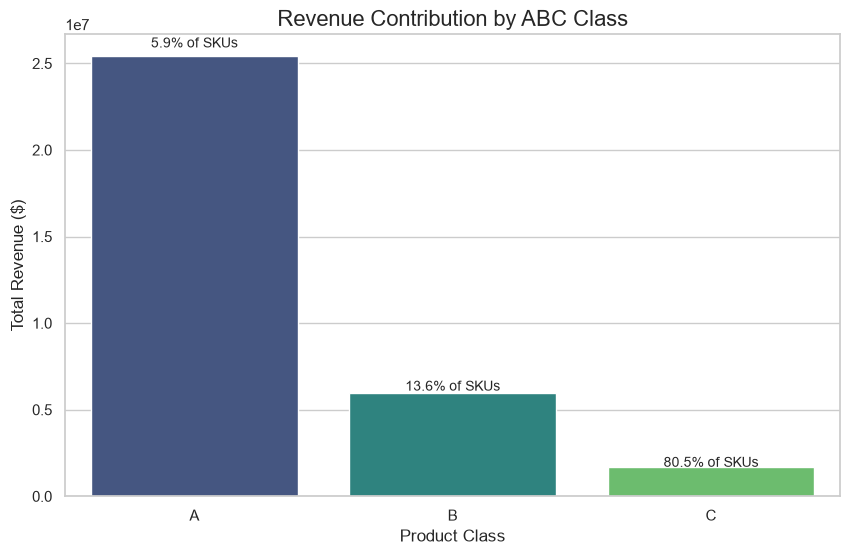

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for revenue per class
sns.barplot(x='ABC_Class', y='Total_Revenue', data=abc_summary, ax=ax1, palette='viridis')
ax1.set_title('Revenue Contribution by ABC Class', fontsize=16)
ax1.set_ylabel('Total Revenue ($)', fontsize=12)
ax1.set_xlabel('Product Class', fontsize=12)

# Add percentage labels on top of bars
for i, p in enumerate(ax1.patches):
    height = p.get_height()
    pct = abc_summary.loc[i, '% of Total Products']
    ax1.text(p.get_x() + p.get_width()/2., height + (height*0.02),
             f"{pct:.1f}% of SKUs", ha="center", fontsize=10)

plt.show()

### 2. Demand Trend Analysis for Top SKUs
Now, let's pick the Top 5 best-selling products (from Class A) and visualize their historical monthly demand. We are looking for:
* **Seasonality:** Do they sell more in summer or winter?
* **Trend:** Is the overall demand growing or shrinking over the years?

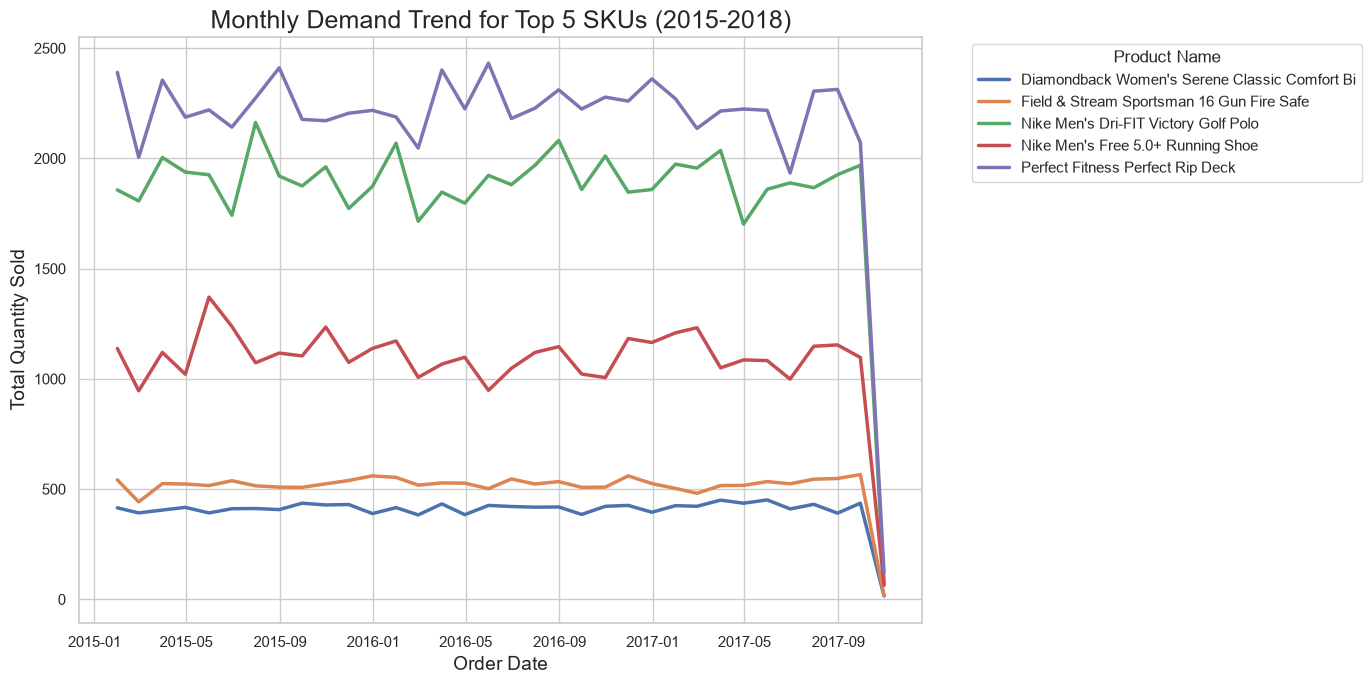

In [4]:
# Extract the Top 5 Product Names
top_5_products = product_sales.head(5)['product_name'].tolist()

# Filter our main dataframe to only include these top 5 products
df_top5 = df[df['product_name'].isin(top_5_products)]

# Set date as index so we can resample (group by month)
df_top5.set_index('order_date', inplace=True)

# Group by Product Name and resample by Month ('ME' for Month End), summing the quantity sold
monthly_demand = df_top5.groupby('product_name')['quantity_sold'].resample('ME').sum().reset_index()

# Plot the trends
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_demand, x='order_date', y='quantity_sold', hue='product_name', linewidth=2.5)

plt.title('Monthly Demand Trend for Top 5 SKUs (2015-2018)', fontsize=18)
plt.ylabel('Total Quantity Sold', fontsize=14)
plt.xlabel('Order Date', fontsize=14)
plt.legend(title='Product Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Summary
1. **ABC Analysis:** We've identified our critical 'Class A' items. Our forecasting priority will be maximizing accuracy on these items to prevent expensive stockouts.
2. **Demand Trends:** Looking at the monthly charts, we can see consistent volume over the years, with some noticeable spikes that our Time Series model (like ARIMA or Prophet) will need to learn to predict.

**Next Step:** Section 3 - Demand Forecasting!